# 06: Priority Prediction Model

**Project Title:** Email Intent Classification with Attention-Based Sequence Models and Priority Prediction  
**Phase Covered:** Phase 7 (Priority Prediction Model)

---

### 🎯 Objectives:
1. Verify presence of urgency/priority annotations in dataset (`urgency` column).
2. Isolate the 1,000 annotated priority emails (`high` -> `High`, `medium` -> `Medium`, `low` -> `Low`).
3. Split priority data into 70% Train, 15% Validation, 15% Test.
4. Build sequence classifier: Embedding -> LSTM -> SimpleAttention -> Dense(3, Softmax).
5. Train model and save `models/priority_model.keras`.
6. Save metrics and confusion matrix plot (`results/figures/priority_confusion_matrix.png`).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Layer
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")

@tf.keras.utils.register_keras_serializable(package="Custom")
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = tf.reduce_sum(inputs * attention_weights, axis=1)
        return context_vector


## 1. Filter Labeled Priority Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_emails.csv")
priority_df = df.dropna(subset=['urgency']).copy()
label_map = {'high': 'High', 'medium': 'Medium', 'low': 'Low'}
priority_df['priority'] = priority_df['urgency'].map(label_map)

print(f"Total Annotated Priority Rows: {len(priority_df)}")
print(priority_df['priority'].value_counts())


Total Annotated Priority Rows: 1000
priority
High      403
Medium    389
Low       208
Name: count, dtype: int64


## 2. Train/Val/Test Split & Tokenization

In [3]:
label_encoder = LabelEncoder()
priority_df['target'] = label_encoder.fit_transform(priority_df['priority'])
joblib.dump(label_encoder, "../models/priority_label_encoder.pkl")

train_df, temp_df = train_test_split(priority_df, test_size=0.30, random_state=42, stratify=priority_df['target'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['target'])

tokenizer = joblib.load("../models/tokenizer.pkl")
max_len = 30

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')

y_train = train_df['target'].values
y_val = val_df['target'].values
y_test = test_df['target'].values


## 3. Build & Train Priority Classifier

In [4]:
num_classes = len(label_encoder.classes_)
max_words = 5000
embedding_dim = 64

inputs = Input(shape=(max_len,), name="priority_input")
x = Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len, name="embedding")(inputs)
lstm_out = LSTM(64, return_sequences=True, name="lstm")(x)
context_vector = SimpleAttention(name="attention")(lstm_out)
x = Dropout(0.3)(context_vector)
x = Dense(32, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax', name="priority_output")(x)

model = Model(inputs=inputs, outputs=outputs, name="Priority_Model")
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model.save("../models/priority_model.keras")


C:\Users\Vivek wadher\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Priority_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ priority_input (InputLayer)     │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (SimpleAttention)     │ (None, 64)             │            94 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ priority_output (Dense)         │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,297 (1.36 MB)

 Trainable params: 355,297 (1.36 MB)

...


 1/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0299


 7/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0215 


14/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9921 - loss: 0.0410


20/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9866 - loss: 0.0544


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9846 - loss: 0.0598 - val_accuracy: 0.6333 - val_loss: 1.6441


## 4. Test Evaluation & Confusion Matrix


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


Accuracy:           0.6800
Weighted Precision: 0.6808
Weighted Recall:    0.6800
Weighted F1-Score:  0.6684


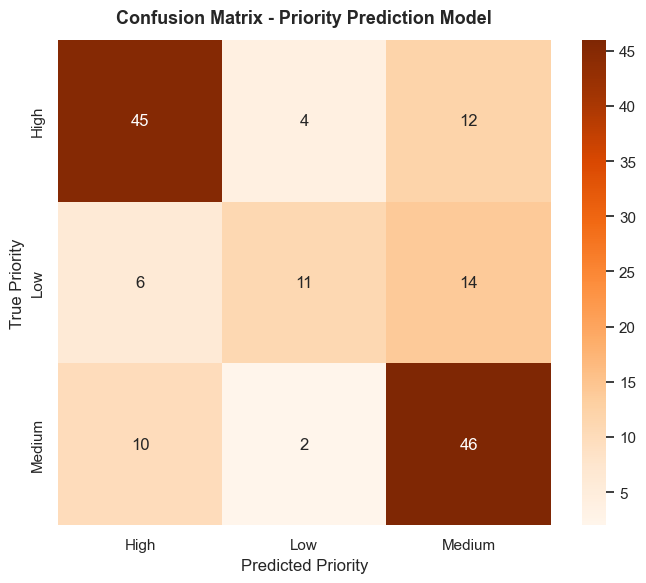

In [5]:
y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print(f"Accuracy:           {acc:.4f}")
print(f"Weighted Precision: {prec_w:.4f}")
print(f"Weighted Recall:    {rec_w:.4f}")
print(f"Weighted F1-Score:  {f1_w:.4f}")

labels = list(label_encoder.classes_)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Priority Prediction Model", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Predicted Priority")
plt.ylabel("True Priority")
plt.tight_layout()
plt.savefig("../results/figures/priority_confusion_matrix.png", dpi=300)
plt.show()

metrics_df = pd.DataFrame([{
    'Model': 'Priority Classifier',
    'Architecture': 'Embedding + LSTM + Attention + Priority Dense',
    'Accuracy': acc,
    'Precision': prec_w,
    'Recall': rec_w,
    'F1_Score': f1_w,
    'Macro_Precision': prec_m,
    'Macro_Recall': rec_m,
    'Macro_F1_Score': f1_m
}])
metrics_df.to_csv("../results/metrics/priority_metrics.csv", index=False)
